# Probabilidad y Estadística II
## Academia de Matemáticas y Estadística Aplicada
## Actividad 2 - Unidad 2
## Diseñada por: Dr. Adrian Ortega
### Nombre y código: __Alan Josué Solano Pérez 224164458__

1. Grafique (en python) la distribución t para los grados de libertad ν = 1, 2, 5. En su gráfica, incluya a la
distribución normal (media cero y varianza uno).

In [1]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

# Configuración para que las gráficas se vean mejor
plt.style.use('seaborn-v0_8-whitegrid')

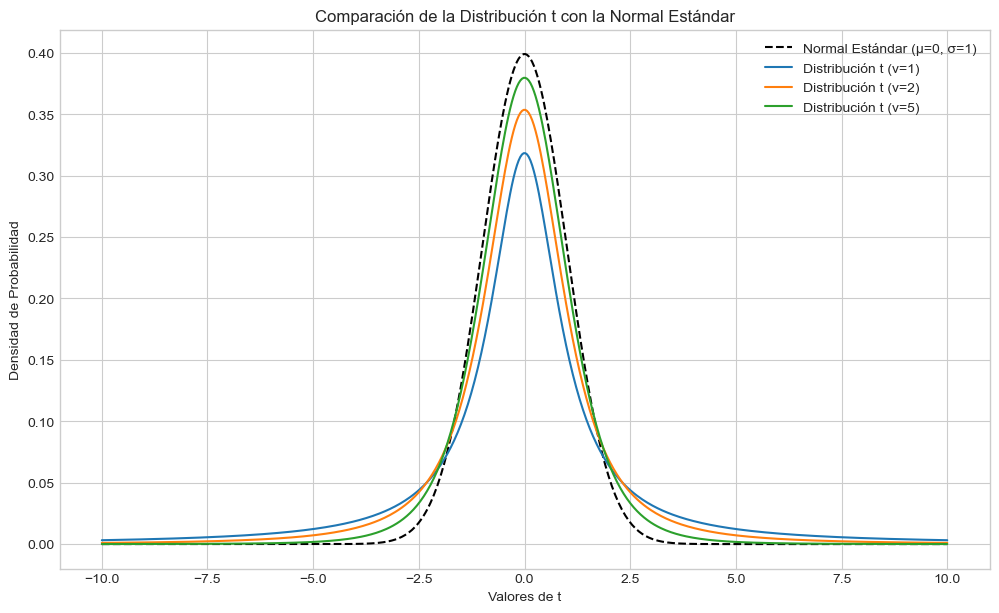

In [2]:
# Definir el rango de valores para el eje x
x = np.linspace(-10, 10, 500)

# Grados de libertad a graficar
grados_libertad = [1, 2, 5]

# Calcular la PDF de la distribución normal estándar
pdf_normal = norm.pdf(x, 0, 1)

# Crear la figura para la gráfica
plt.figure(figsize=(12, 7))

# Graficar la distribución normal
plt.plot(x, pdf_normal, label='Normal Estándar (μ=0, σ=1)', color='black', linestyle='--')

# Graficar las distribuciones t para cada grado de libertad
for df in grados_libertad:
    pdf_t = t.pdf(x, df)
    plt.plot(x, pdf_t, label=f'Distribución t (ν={df})')

# Añadir títulos y etiquetas
plt.title('Comparación de la Distribución t con la Normal Estándar')
plt.xlabel('Valores de t')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.show()

2. Repita la gráfica anterior pero ahora con el eje y en escala logaritmica (escala semi-log). ¿Qué diferencias
encuentra entre la distribución t y la curva normal?

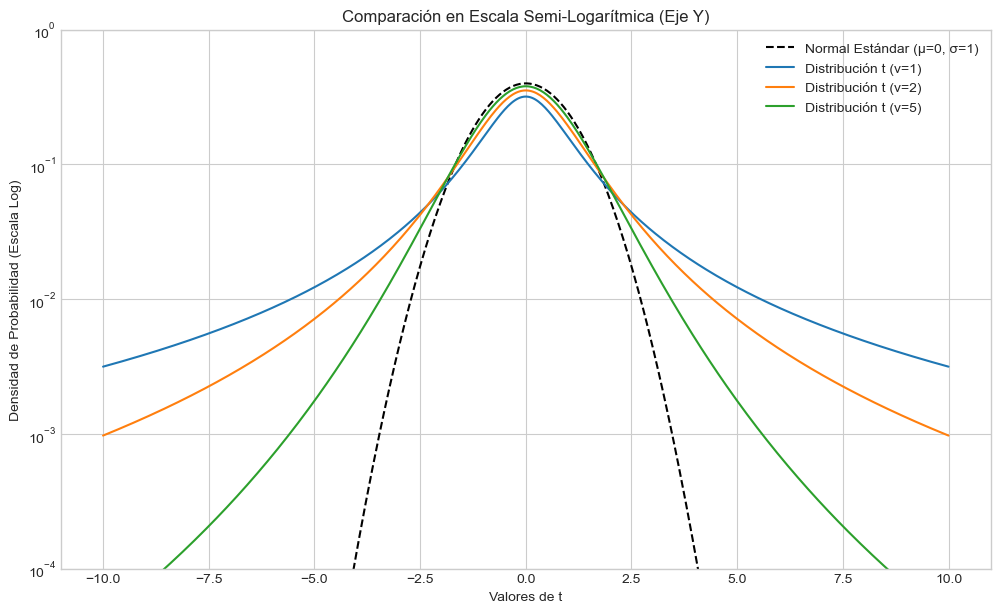

In [3]:
# Crear la figura para la gráfica
plt.figure(figsize=(12, 7))

# Graficar la distribución normal
plt.plot(x, pdf_normal, label='Normal Estándar (μ=0, σ=1)', color='black', linestyle='--')

# Graficar las distribuciones t para cada grado de libertad
for df in grados_libertad:
    pdf_t = t.pdf(x, df)
    plt.plot(x, pdf_t, label=f'Distribución t (ν={df})')

# --- La única diferencia: cambiar la escala del eje y a logarítmica ---
plt.yscale('log')

# Añadir títulos y etiquetas
plt.title('Comparación en Escala Semi-Logarítmica (Eje Y)')
plt.xlabel('Valores de t')
plt.ylabel('Densidad de Probabilidad (Escala Log)')
plt.ylim(0.0001, 1) # Ajustar límites para una mejor visualización
plt.legend()
plt.show()

3. Encuentre (numéricamente) la probabilidad de que una variable aleatoria T con distribución t (ν = 14)
se encuentre entre los valores de −t0.025 y t0.05. En su resultado final se debe escribir las integrales
necesarias para calcular la probabilidad mencionada.

In [4]:
# Grados de libertad
df = 14

# Encontrar los valores críticos t
# t_alpha es el valor t tal que P(T > t_alpha) = alpha
# scipy.stats.t.ppf(q, df) nos da el valor t para una probabilidad acumulada q
t_0_05 = t.ppf(1 - 0.05, df=df)
t_0_025 = t.ppf(1 - 0.025, df=df)

# El límite inferior es -t_0.025
limite_inferior = -t_0_025
limite_superior = t_0_05

# Calcular la probabilidad usando la CDF (Cumulative Distribution Function)
# P(a < T < b) = CDF(b) - CDF(a)
probabilidad = t.cdf(limite_superior, df=df) - t.cdf(limite_inferior, df=df)

print(f"Grados de libertad (ν): {df}")
print(f"Valor crítico t_0.05: {t_0_05:.4f}")
print(f"Valor crítico t_0.025: {t_0_025:.4f}")
print(f"Límite inferior (-t_0.025): {limite_inferior:.4f}")
print(f"Límite superior (t_0.05): {limite_superior:.4f}")
print("-" * 30)
print(f"La probabilidad P({limite_inferior:.4f} < T < {limite_superior:.4f}) es: {probabilidad:.4f}")

Grados de libertad (ν): 14
Valor crítico t_0.05: 1.7613
Valor crítico t_0.025: 2.1448
Límite inferior (-t_0.025): -2.1448
Límite superior (t_0.05): 1.7613
------------------------------
La probabilidad P(-2.1448 < T < 1.7613) es: 0.9250


4. Una población normal con varianza desconocida tiene una media de 20. ¿Se tiene posibilidad de obtener
una muestra aleatoria de tamaño 9 de esta población con una media de 24 y una desviación estándar de
4.1?

In [5]:
# Datos del problema
mu0 = 20
n = 9
x_bar = 24
s = 4.1
df = n - 1

# Calcular el error estándar de la media
error_estandar = s / np.sqrt(n)

# Calcular el estadístico t
t_stat = (x_bar - mu0) / error_estandar

# Calcular la probabilidad (p-value) de obtener este resultado o uno más extremo.
# Usamos una prueba de dos colas porque no se especificó la dirección.
# P(|T| > |t_stat|) = 2 * (1 - CDF(|t_stat|))
p_value = 2 * (1 - t.cdf(abs(t_stat), df=df))

print(f"Datos: μ₀={mu0}, n={n}, x̄={x_bar}, s={s}")
print(f"Grados de libertad (ν): {df}")
print(f"Estadístico t calculado: {t_stat:.4f}")
print(f"Probabilidad (p-value de dos colas): {p_value:.4f}")

Datos: μ₀=20, n=9, x̄=24, s=4.1
Grados de libertad (ν): 8
Estadístico t calculado: 2.9268
Probabilidad (p-value de dos colas): 0.0191


5. Una industria manufactura focos. El CEO de la empresa asegura que un foco promedio de la marca dura 300 días. Un investigador selecciona 15 focos para prueba. Los focos probados duran un promedio de 290 días, con una desviación estándar de 50. Si la declaración del CEO fuese verdad, ¿cuál es la probabilidad de que 15 focos seleccionados al azar tengan una vida promedio de no más de 290 días?

In [6]:
# Datos del problema
mu0 = 300
n = 15
x_bar = 290
s = 50
df = n - 1

# Calcular el error estándar de la media
error_estandar_focos = s / np.sqrt(n)

# Calcular el estadístico t
t_stat_focos = (x_bar - mu0) / error_estandar_focos

# Calcular la probabilidad de que la media sea no más de 290.
# Esto es P(T <= t_stat_focos), que es la CDF en el valor t calculado.
prob_focos = t.cdf(t_stat_focos, df=df)

print(f"Datos: μ₀={mu0}, n={n}, x̄={x_bar}, s={s}")
print(f"Grados de libertad (ν): {df}")
print(f"Estadístico t calculado: {t_stat_focos:.4f}")
print(f"La probabilidad de que la vida promedio sea no más de 290 días es: {prob_focos:.4f}")

Datos: μ₀=300, n=15, x̄=290, s=50
Grados de libertad (ν): 14
Estadístico t calculado: -0.7746
La probabilidad de que la vida promedio sea no más de 290 días es: 0.2257
